# Monte Carlo Simulation for Short after 1 day strategy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
# Load your data
# df = pd.read_csv('../data/dataset_storage/final/all_matched_data.csv')
df = df_bitget = pd.read_csv('../data/data_storage_bitget/final/all_matched_data.csv')
df

,ts_since_listing,low,btc_close,timestamp,close,btc_volume,eth_volume,fng,instrument_id,sol_volume,eth_close,open,sol_close,volume,doge_close,high,doge_volume
0,1,2.6328,117318.9,2025-09-18 04:15:00,2.6328,1019.9594,11068.19,52,0GUSDT-LINEAR,126208.0,4605.01,2.7590,245.6220,310.0,0.282360,2.7601,23984206.0
1,2,2.4493,117386.8,2025-09-18 04:30:00,2.4576,1319.2133,19359.20,52,0GUSDT-LINEAR,58020.0,4602.95,2.6328,245.7450,3544.0,0.282570,2.6830,16113812.0
2,3,2.3035,117575.5,2025-09-18 04:45:00,2.3322,485.7379,9298.12,52,0GUSDT-LINEAR,46847.4,4609.59,2.4576,246.1410,2954.0,0.282470,2.5076,17644389.0
3,4,2.2440,117394.8,2025-09-18 05:00:00,2.5572,1084.0386,2782.20,52,0GUSDT-LINEAR,22299.4,4600.14,2.3322,245.6390,3872.0,0.281950,2.5572,7901566.0
4,5,2.3310,117188.5,2025-09-18 05:15:00,2.4402,915.1415,10865.31,52,0GUSDT-LINEAR,94820.9,4588.76,2.5572,244.8170,3732.0,0.280720,2.5572,11185701.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950496,2707,3.9240,64066.1,2024-07-18 22:30:00,3.9440,1110.9960,2023.94,61,ZROUSDT-LINEAR,47428.5,3435.00,3.9320,160.0827,13585.0,0.120027,3.9450,2826009.0
950497,2708,3.9220,63987.1,2024-07-18 22:45:00,3.9290,610.0390,1692.80,61,ZROUSDT-LINEAR,10824.2,3431.09,3.9440,159.7526,10006.0,0.119769,3.9460,1420539.0
950498,2709,3.9250,63927.8,2024-07-18 23:00:00,3.9300,621.9840,5359.43,61,ZROUSDT-LINEAR,6967.9,3430.08,3.9290,159.7099,4410.0,0.119842,3.9370,811024.0
950499,2710,3.9170,63957.2,2024-07-18 23:15:00,3.9190,281.4880,1733.86,61,ZROUSDT-LINEAR,11697.1,3433.34,3.9300,159.2318,2954.0,0.119772,3.9300,259581.0


### Calculate Stats

In [88]:
# Convert timestamp to datetime if needed
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by instrument and timestamp
df = df.sort_values(['instrument_id', 'timestamp']).reset_index(drop=True)

results = []

for instrument, group in df.groupby('instrument_id'):
    group = group.reset_index(drop=True)
    
    if len(group) < 2:
        continue
    
    # Get first timestamp
    t0 = group['timestamp'].iloc[0]
    t1 = t0 + pd.Timedelta(days=1)
    
    # FIRST DAY = all rows in first 24 hours
    first_day = group[(group['timestamp'] >= t0) & (group['timestamp'] <= t1)]
    
    if first_day.empty:
        continue
    
    # Stop level = max high across entire first day
    stop_level = first_day['high'].max()
    data_start_date = t0
    
    # AFTER first day
    after_first_day = group[group['timestamp'] > t1]
    
    if after_first_day.empty:
        continue  # Need data after first day to enter trade
    
    # Entry = first close AFTER the first day ends
    entry_row = after_first_day.iloc[0]
    entry_date = entry_row['timestamp']
    entry_price = entry_row['close']
    
    # Check all days AFTER entry (from index 1 onwards in after_first_day)
    if len(after_first_day) > 1:
        days_after_entry = after_first_day.iloc[1:]
        # Stop hit if any high > first day's max high
        stop_hit = (days_after_entry['high'] > stop_level).any()
    else:
        stop_hit = False
    
    if stop_hit:
        trade_return = -1.0  # Lost risked amount
    else:
        # Calculate return from short position
        final_price = group.iloc[-1]['close']
        # Short return = (entry - exit) / entry
        trade_return = (entry_price - final_price) / (stop_level - entry_price) #XXX Changed
        # print(f"Adding {trade_return}") 

    results.append({
        'instrument_id': instrument,
        'data_start_date': data_start_date,
        'entry_date': entry_date,
        'entry_price': entry_price,
        'stop_level': stop_level,
        'final_price': group.iloc[-1]['close'],
        'trade_return': trade_return,
        'stop_hit': stop_hit,
        'days_held': len(group) - len(first_day)
    })

# Create results dataframe
results_df = pd.DataFrame(results)

# Split by DATA START DATE
cutoff_date = pd.to_datetime('2025-06-01')
before_cutoff = results_df[results_df['data_start_date'] < cutoff_date]
after_cutoff = results_df[results_df['data_start_date'] >= cutoff_date]

In [89]:
def calculate_rr_stats(df_subset):
    """Calculate RR ratio statistics"""
    winners = df_subset[~df_subset['stop_hit']]
    losers = df_subset[df_subset['stop_hit']]
    
    avg_win = winners['trade_return'].mean() if len(winners) > 0 else 0
    avg_loss = -1.0  # Always -1 for stopped trades
    win_rate = len(winners) / len(df_subset) if len(df_subset) > 0 else 0
    
    # RR Ratio = Average Win / Average Loss (absolute value)
    rr_ratio = avg_win / abs(avg_loss) if avg_loss != 0 else 0
    
    # Expected Value = (Win Rate × Avg Win) + (Loss Rate × Avg Loss)
    expected_value = (win_rate * avg_win) + ((1 - win_rate) * avg_loss)
    
    return {
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'win_rate': win_rate,
        'rr_ratio': rr_ratio,
        'expected_value': expected_value
    }

# Calculate average returns
print("=" * 60)
print("SHORTING STRATEGY RESULTS")
print("=" * 60)

print(f"\nCOINS WITH DATA STARTING BEFORE 2025-06-01:")
print(f"   Total coins: {len(before_cutoff)}")
if len(before_cutoff) > 0:
    stats_before = calculate_rr_stats(before_cutoff)
    print(f"   Average Return: {before_cutoff['trade_return'].mean():.4f} ({before_cutoff['trade_return'].mean()*100:.2f}%)")
    print(f"   Stop hits: {before_cutoff['stop_hit'].sum()} ({before_cutoff['stop_hit'].sum()/len(before_cutoff)*100:.1f}%)")
    print(f"   Avg days held: {before_cutoff['days_held'].mean():.1f}")
    print(f"   ---")
    print(f"   Average Win (no stop): {stats_before['avg_win']:.4f} ({stats_before['avg_win']*100:.2f}%)")
    print(f"   Average Loss (stop): {stats_before['avg_loss']:.4f} ({stats_before['avg_loss']*100:.2f}%)")
    print(f"   Win Rate: {stats_before['win_rate']*100:.1f}%")
    print(f"   RR Ratio: {stats_before['rr_ratio']:.4f}")
    print(f"   Expected Value: {stats_before['expected_value']:.4f} ({stats_before['expected_value']*100:.2f}%)")

print(f"\nCOINS WITH DATA STARTING ON/AFTER 2025-06-01:")
print(f"   Total coins: {len(after_cutoff)}")
if len(after_cutoff) > 0:
    stats_after = calculate_rr_stats(after_cutoff)
    print(f"   Average Return: {after_cutoff['trade_return'].mean():.4f} ({after_cutoff['trade_return'].mean()*100:.2f}%)")
    print(f"   Stop hits: {after_cutoff['stop_hit'].sum()} ({after_cutoff['stop_hit'].sum()/len(after_cutoff)*100:.1f}%)")
    print(f"   Avg days held: {after_cutoff['days_held'].mean():.1f}")
    print(f"   ---")
    print(f"   Average Win (no stop): {stats_after['avg_win']:.4f} ({stats_after['avg_win']*100:.2f}%)")
    print(f"   Average Loss (stop): {stats_after['avg_loss']:.4f} ({stats_after['avg_loss']*100:.2f}%)")
    print(f"   Win Rate: {stats_after['win_rate']*100:.1f}%")
    print(f"   RR Ratio: {stats_after['rr_ratio']:.4f}")
    print(f"   Expected Value: {stats_after['expected_value']:.4f} ({stats_after['expected_value']*100:.2f}%)")

print(f"\nRETURN DISTRIBUTION (All trades):")
print(results_df['trade_return'].describe())

print(f"\nWINNERS vs LOSERS:")
print(f"   Profitable trades: {(results_df['trade_return'] > 0).sum()}")
print(f"   Losing trades: {(results_df['trade_return'] <= 0).sum()}")
print(f"   Win rate: {(results_df['trade_return'] > 0).sum()/len(results_df)*100:.1f}%")


# Verify against your function
rr_before = stats_before['rr_ratio']
rr_after = stats_after['rr_ratio']

SHORTING STRATEGY RESULTS

COINS WITH DATA STARTING BEFORE 2025-06-01:
   Total coins: 238
   Average Return: 0.1112 (11.12%)
   Stop hits: 147 (61.8%)
   Avg days held: 2630.4
   ---
   Average Win (no stop): 1.9062 (190.62%)
   Average Loss (stop): -1.0000 (-100.00%)
   Win Rate: 38.2%
   RR Ratio: 1.9062
   Expected Value: 0.1112 (11.12%)

COINS WITH DATA STARTING ON/AFTER 2025-06-01:
   Total coins: 116
   Average Return: 0.2148 (21.48%)
   Stop hits: 61 (52.6%)
   Avg days held: 2504.9
   ---
   Average Win (no stop): 1.5621 (156.21%)
   Average Loss (stop): -1.0000 (-100.00%)
   Win Rate: 47.4%
   RR Ratio: 1.5621
   Expected Value: 0.2148 (21.48%)

RETURN DISTRIBUTION (All trades):
count    354.000000
mean       0.145129
std        1.983349
min       -1.000000
25%       -1.000000
50%       -1.000000
75%        0.814882
max       15.861369
Name: trade_return, dtype: float64

WINNERS vs LOSERS:
   Profitable trades: 141
   Losing trades: 213
   Win rate: 39.8%


## Monte Carlo 

### Calculation

In [ ]:
# PARAMETERS
STARTING_CAPITAL = 100
RISK_PCT = 0.05
NUM_SIMULATIONS = 500

# Before cutoff stats
before_num_trades = 238
before_win_rate = 0.382
before_avg_win = 1.9062
before_avg_loss = -1.0

# After cutoff stats
after_num_trades = 116
after_win_rate = 0.474
after_avg_win = 1.5621
after_avg_loss = -1.0

def monte_carlo_simulation(num_trades, win_rate, avg_win_rr, avg_loss_rr, 
                           starting_capital=100, risk_pct=0.05, num_simulations=100):
    """
    Run Monte Carlo simulation for trading strategy
    
    Parameters:
    - num_trades: number of trades to execute
    - win_rate: probability of winning trade
    - avg_win_rr: average win in R (risk units)
    - avg_loss_rr: average loss in R (should be -1)
    - starting_capital: initial capital
    - risk_pct: percentage of capital to risk per trade
    - num_simulations: number of simulation runs
    """
    
    all_runs = []
    final_capitals = []
    
    for sim in range(num_simulations):
        capital = starting_capital
        capital_history = [capital]
        
        for trade in range(num_trades):
            risk_amount = capital * risk_pct
            
            # Randomly determine if trade wins or loses
            if np.random.random() < win_rate:
                # Win
                profit = risk_amount * avg_win_rr
                capital += profit
            else:
                # Loss
                loss = risk_amount * abs(avg_loss_rr)
                capital -= loss
            
            capital_history.append(capital)
        
        all_runs.append(capital_history)
        final_capitals.append(capital)
    
    return np.array(all_runs), np.array(final_capitals)

# Run simulations
print("Running Monte Carlo Simulations...")
before_runs, before_finals = monte_carlo_simulation(
    before_num_trades, before_win_rate, before_avg_win, before_avg_loss,
    STARTING_CAPITAL, RISK_PCT, NUM_SIMULATIONS
)

after_runs, after_finals = monte_carlo_simulation(
    after_num_trades, after_win_rate, after_avg_win, after_avg_loss,
    STARTING_CAPITAL, RISK_PCT, NUM_SIMULATIONS
)

# Statistics
print("\nBEFORE CUTOFF (238 trades):")
print(f"   Starting Capital: ${STARTING_CAPITAL:.2f}")
print(f"   Risk per trade: {RISK_PCT*100:.1f}%")
print(f"   Win Rate: {before_win_rate*100:.1f}%")
print(f"   Avg Win: {before_avg_win:.4f}R")
print(f"   Expected Value per trade: {stats_before['expected_value']:.4f}R")
print(f"\n   Final Capital Statistics (1000 Simulations):")
print(f"   Mean: ${before_finals.mean():.2f}")
print(f"   Median: ${np.median(before_finals):.2f}")
print(f"   Std Dev: ${before_finals.std():.2f}")
print(f"   Min: ${before_finals.min():.2f}")
print(f"   Max: ${before_finals.max():.2f}")
print(f"   Profitable runs: {(before_finals > STARTING_CAPITAL).sum()}/100 ({(before_finals > STARTING_CAPITAL).sum()}%)")
print(f"   Average Return: {((before_finals.mean() - STARTING_CAPITAL) / STARTING_CAPITAL * 100):.2f}%")

print("\nAFTER CUTOFF (116 trades):")
print(f"   Starting Capital: ${STARTING_CAPITAL:.2f}")
print(f"   Risk per trade: {RISK_PCT*100:.1f}%")
print(f"   Win Rate: {after_win_rate*100:.1f}%")
print(f"   Avg Win: {after_avg_win:.4f}R")
print(f"   Expected Value per trade: {stats_after['expected_value']:.4f}R")
print(f"\n   Final Capital Statistics (1000 Simulations):")
print(f"   Mean: ${after_finals.mean():.2f}")
print(f"   Median: ${np.median(after_finals):.2f}")
print(f"   Std Dev: ${after_finals.std():.2f}")
print(f"   Min: ${after_finals.min():.2f}")
print(f"   Max: ${after_finals.max():.2f}")
print(f"   Profitable runs: {(after_finals > STARTING_CAPITAL).sum()}/100 ({(after_finals > STARTING_CAPITAL).sum()}%)")
print(f"   Average Return: {((after_finals.mean() - STARTING_CAPITAL) / STARTING_CAPITAL * 100):.2f}%")

Running Monte Carlo Simulations...

BEFORE CUTOFF (238 trades):
   Starting Capital: $100.00
   Risk per trade: 5.0%
   Win Rate: 38.2%
   Avg Win: 1.9062R
   Expected Value per trade: 0.1112R

   Final Capital Statistics (100 simulations):
   Mean: $328.44
   Median: $182.57
   Std Dev: $473.42
   Min: $9.19
   Max: $5558.42
   Profitable runs: 364/100 (364%)
   Average Return: 228.44%

AFTER CUTOFF (116 trades):
   Starting Capital: $100.00
   Risk per trade: 5.0%
   Win Rate: 47.4%
   Avg Win: 1.5621R
   Expected Value per trade: 0.2148R

   Final Capital Statistics (100 simulations):
   Mean: $347.71
   Median: $273.84
   Std Dev: $272.27
   Min: $24.76
   Max: $2351.99
   Profitable runs: 464/100 (464%)
   Average Return: 247.71%


### Visualization

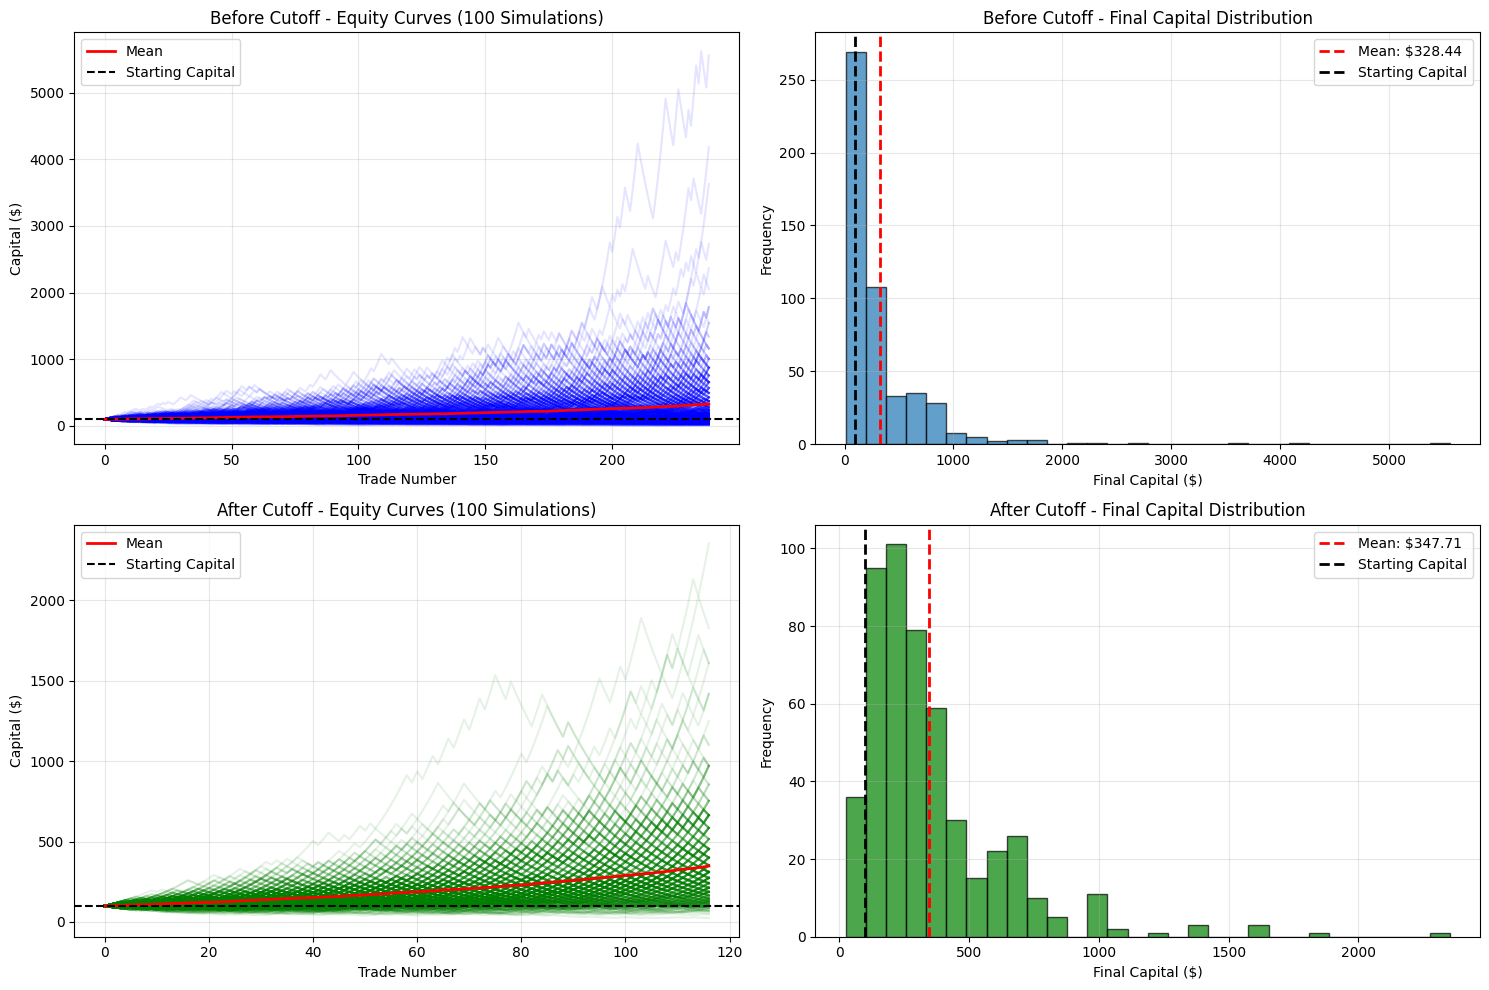


Visualization saved as 'monte_carlo_simulation.png'

PERCENTILE ANALYSIS:

Before Cutoff:
   5th percentile: $33.09 (-66.91%)
   25th percentile: $89.61 (-10.39%)
   50th percentile: $182.57 (+82.57%)
   75th percentile: $371.96 (+271.96%)
   95th percentile: $1007.37 (+907.37%)

After Cutoff:
   5th percentile: $99.54 (-0.46%)
   25th percentile: $165.10 (+65.10%)
   50th percentile: $273.84 (+173.84%)
   75th percentile: $454.20 (+354.20%)
   95th percentile: $854.94 (+754.94%)


In [ ]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Before cutoff - equity curves
ax1 = axes[0, 0]
for run in before_runs:
    ax1.plot(run, alpha=0.1, color='blue')
ax1.plot(before_runs.mean(axis=0), color='red', linewidth=2, label='Mean')
ax1.axhline(y=STARTING_CAPITAL, color='black', linestyle='--', label='Starting Capital')
ax1.set_title('Before Cutoff - Equity Curves (1000 Simulations)')
ax1.set_xlabel('Trade Number')
ax1.set_ylabel('Capital ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Before cutoff - final capital distribution
ax2 = axes[0, 1]
ax2.hist(before_finals, bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(x=before_finals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${before_finals.mean():.2f}')
ax2.axvline(x=STARTING_CAPITAL, color='black', linestyle='--', linewidth=2, label='Starting Capital')
ax2.set_title('Before Cutoff - Final Capital Distribution')
ax2.set_xlabel('Final Capital ($)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# After cutoff - equity curves
ax3 = axes[1, 0]
for run in after_runs:
    ax3.plot(run, alpha=0.1, color='green')
ax3.plot(after_runs.mean(axis=0), color='red', linewidth=2, label='Mean')
ax3.axhline(y=STARTING_CAPITAL, color='black', linestyle='--', label='Starting Capital')
ax3.set_title('After Cutoff - Equity Curves (1000 Simulations)')
ax3.set_xlabel('Trade Number')
ax3.set_ylabel('Capital ($)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# After cutoff - final capital distribution
ax4 = axes[1, 1]
ax4.hist(after_finals, bins=30, edgecolor='black', alpha=0.7, color='green')
ax4.axvline(x=after_finals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${after_finals.mean():.2f}')
ax4.axvline(x=STARTING_CAPITAL, color='black', linestyle='--', linewidth=2, label='Starting Capital')
ax4.set_title('After Cutoff - Final Capital Distribution')
ax4.set_xlabel('Final Capital ($)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monte_carlo_simulation_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'monte_carlo_simulation_baseline.png'")

print("\nPERCENTILE ANALYSIS:")
print("\nBefore Cutoff:")
for percentile in [5, 25, 50, 75, 95]:
    value = np.percentile(before_finals, percentile)
    print(f"   {percentile}th percentile: ${value:.2f} ({((value-STARTING_CAPITAL)/STARTING_CAPITAL*100):+.2f}%)")

print("\nAfter Cutoff:")
for percentile in [5, 25, 50, 75, 95]:
    value = np.percentile(after_finals, percentile)
    print(f"   {percentile}th percentile: ${value:.2f} ({((value-STARTING_CAPITAL)/STARTING_CAPITAL*100):+.2f}%)")

## ML Based Monte Carlo

In [118]:
# PARAMETERS
STARTING_CAPITAL = 100
RISK_PCT = 0.05
NUM_SIMULATIONS = 1000

# After cutoff stats
after_num_trades = int(116 * 0.543)
after_win_rate = 0.762
after_avg_win = 1.5621
after_avg_loss = -1.0

def monte_carlo_simulation(num_trades, win_rate, avg_win_rr, avg_loss_rr, 
                           starting_capital=100, risk_pct=0.05, num_simulations=100):
    """
    Run Monte Carlo simulation for trading strategy
    
    Parameters:
    - num_trades: number of trades to execute
    - win_rate: probability of winning trade
    - avg_win_rr: average win in R (risk units)
    - avg_loss_rr: average loss in R (should be -1)
    - starting_capital: initial capital
    - risk_pct: percentage of capital to risk per trade
    - num_simulations: number of simulation runs
    """
    
    all_runs = []
    final_capitals = []
    
    for sim in range(num_simulations):
        capital = starting_capital
        capital_history = [capital]
        
        for trade in range(num_trades):
            risk_amount = capital * risk_pct
            
            # Randomly determine if trade wins or loses
            if np.random.random() < win_rate:
                # Win
                profit = risk_amount * avg_win_rr
                capital += profit
            else:
                # Loss
                loss = risk_amount * abs(avg_loss_rr)
                capital -= loss
            
            capital_history.append(capital)
        
        all_runs.append(capital_history)
        final_capitals.append(capital)
    
    return np.array(all_runs), np.array(final_capitals)

# Run simulations
print("Running Monte Carlo Simulations...")
before_runs, before_finals = monte_carlo_simulation(
    before_num_trades, before_win_rate, before_avg_win, before_avg_loss,
    STARTING_CAPITAL, RISK_PCT, NUM_SIMULATIONS
)

after_runs, after_finals = monte_carlo_simulation(
    after_num_trades, after_win_rate, after_avg_win, after_avg_loss,
    STARTING_CAPITAL, RISK_PCT, NUM_SIMULATIONS
)

# Statistics
print("\nBEFORE CUTOFF (238 trades):")
print(f"   Starting Capital: ${STARTING_CAPITAL:.2f}")
print(f"   Risk per trade: {RISK_PCT*100:.1f}%")
print(f"   Win Rate: {before_win_rate*100:.1f}%")
print(f"   Avg Win: {before_avg_win:.4f}R")
print(f"   Expected Value per trade: {stats_before['expected_value']:.4f}R")
print(f"\n   Final Capital Statistics (1000 Simulations):")
print(f"   Mean: ${before_finals.mean():.2f}")
print(f"   Median: ${np.median(before_finals):.2f}")
print(f"   Std Dev: ${before_finals.std():.2f}")
print(f"   Min: ${before_finals.min():.2f}")
print(f"   Max: ${before_finals.max():.2f}")
print(f"   Profitable runs: {(before_finals > STARTING_CAPITAL).sum()}/100 ({(before_finals > STARTING_CAPITAL).sum()}%)")
print(f"   Average Return: {((before_finals.mean() - STARTING_CAPITAL) / STARTING_CAPITAL * 100):.2f}%")

print("\nAFTER CUTOFF (116 trades):")
print(f"   Starting Capital: ${STARTING_CAPITAL:.2f}")
print(f"   Risk per trade: {RISK_PCT*100:.1f}%")
print(f"   Win Rate: {after_win_rate*100:.1f}%")
print(f"   Avg Win: {after_avg_win:.4f}R")
print(f"   Expected Value per trade: {stats_after['expected_value']:.4f}R")
print(f"\n   Final Capital Statistics (1000 Simulations):")
print(f"   Mean: ${after_finals.mean():.2f}")
print(f"   Median: ${np.median(after_finals):.2f}")
print(f"   Std Dev: ${after_finals.std():.2f}")
print(f"   Min: ${after_finals.min():.2f}")
print(f"   Max: ${after_finals.max():.2f}")
print(f"   Profitable runs: {(after_finals > STARTING_CAPITAL).sum()}/100 ({(after_finals > STARTING_CAPITAL).sum()}%)")
print(f"   Average Return: {((after_finals.mean() - STARTING_CAPITAL) / STARTING_CAPITAL * 100):.2f}%")

Running Monte Carlo Simulations...

BEFORE CUTOFF (238 trades):
   Starting Capital: $100.00
   Risk per trade: 5.0%
   Win Rate: 38.2%
   Avg Win: 1.9062R
   Expected Value per trade: 0.1112R

   Final Capital Statistics (1000 Simulations):
   Mean: $377.13
   Median: $182.57
   Std Dev: $555.08
   Min: $10.60
   Max: $4821.01
   Profitable runs: 740/100 (740%)
   Average Return: 277.13%

AFTER CUTOFF (116 trades):
   Starting Capital: $100.00
   Risk per trade: 5.0%
   Win Rate: 76.2%
   Avg Win: 1.5621R
   Expected Value per trade: 0.2148R

   Final Capital Statistics (1000 Simulations):
   Mean: $1780.51
   Median: $1588.27
   Std Dev: $770.40
   Min: $306.72
   Max: $4958.62
   Profitable runs: 1000/100 (1000%)
   Average Return: 1680.51%


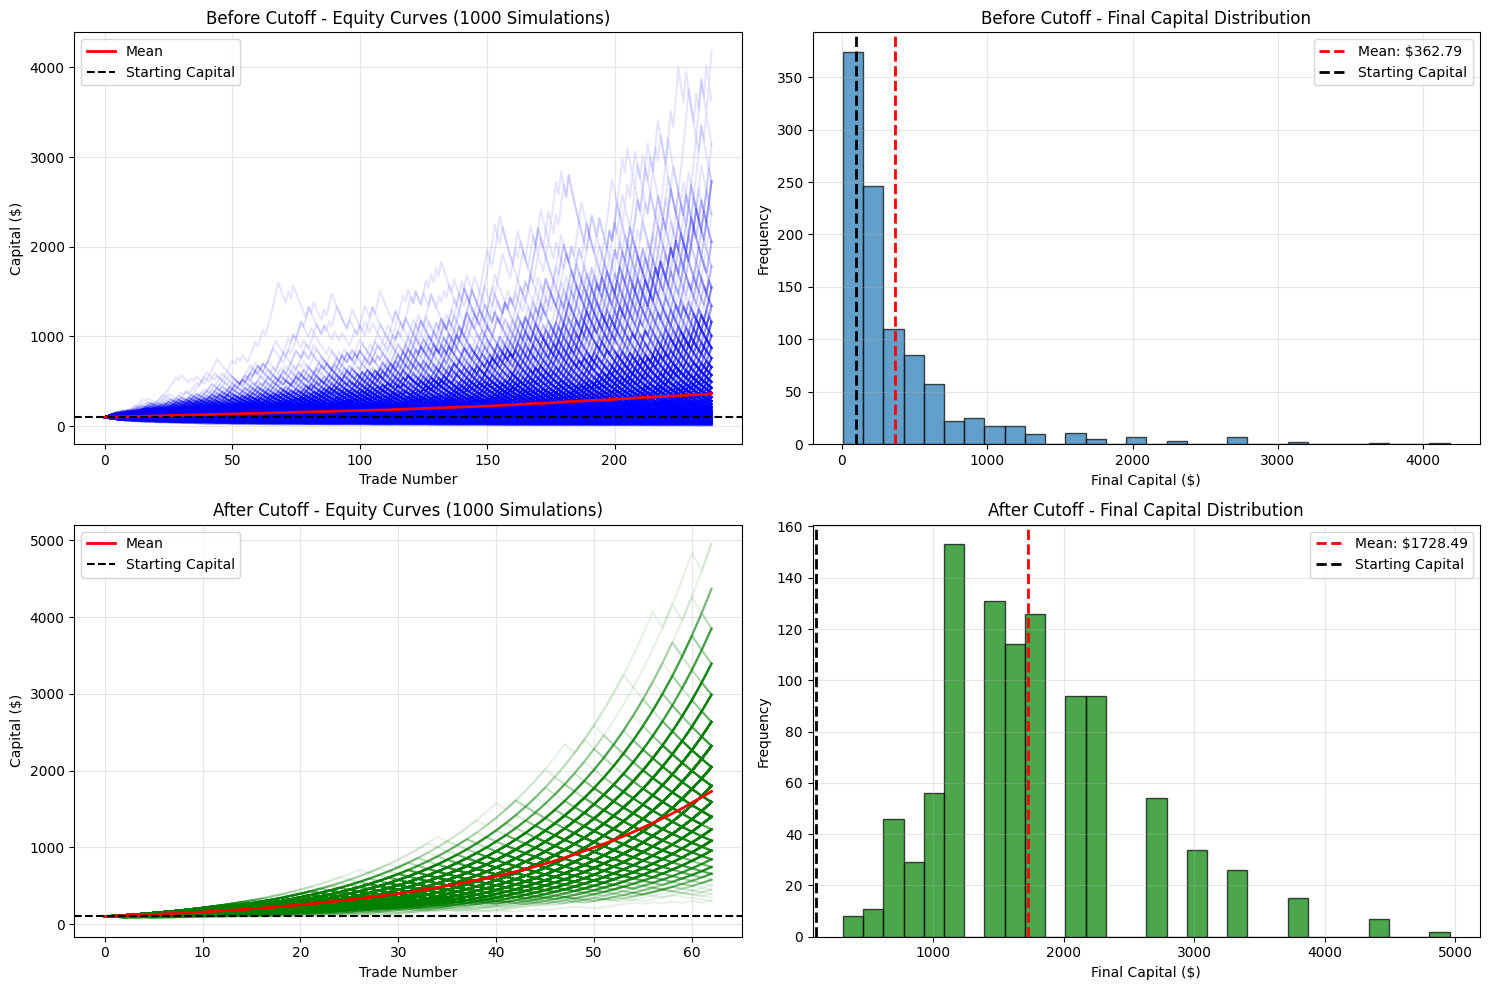


Visualization saved as 'monte_carlo_simulation_ml.png'

PERCENTILE ANALYSIS:

Before Cutoff:
   5th percentile: $38.15 (-61.85%)
   25th percentile: $103.32 (+3.32%)
   50th percentile: $210.49 (+110.49%)
   75th percentile: $428.85 (+328.85%)
   95th percentile: $1161.46 (+1061.46%)

After Cutoff:
   5th percentile: $743.53 (+643.53%)
   25th percentile: $1233.24 (+1133.24%)
   50th percentile: $1588.27 (+1488.27%)
   75th percentile: $2045.50 (+1945.50%)
   95th percentile: $3009.74 (+2909.74%)


In [117]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Before cutoff - equity curves
ax1 = axes[0, 0]
for run in before_runs:
    ax1.plot(run, alpha=0.1, color='blue')
ax1.plot(before_runs.mean(axis=0), color='red', linewidth=2, label='Mean')
ax1.axhline(y=STARTING_CAPITAL, color='black', linestyle='--', label='Starting Capital')
ax1.set_title('Before Cutoff - Equity Curves (1000 Simulations)')
ax1.set_xlabel('Trade Number')
ax1.set_ylabel('Capital ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Before cutoff - final capital distribution
ax2 = axes[0, 1]
ax2.hist(before_finals, bins=30, edgecolor='black', alpha=0.7)
ax2.axvline(x=before_finals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${before_finals.mean():.2f}')
ax2.axvline(x=STARTING_CAPITAL, color='black', linestyle='--', linewidth=2, label='Starting Capital')
ax2.set_title('Before Cutoff - Final Capital Distribution')
ax2.set_xlabel('Final Capital ($)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# After cutoff - equity curves
ax3 = axes[1, 0]
for run in after_runs:
    ax3.plot(run, alpha=0.1, color='green')
ax3.plot(after_runs.mean(axis=0), color='red', linewidth=2, label='Mean')
ax3.axhline(y=STARTING_CAPITAL, color='black', linestyle='--', label='Starting Capital')
ax3.set_title('After Cutoff - Equity Curves (1000 Simulations)')
ax3.set_xlabel('Trade Number')
ax3.set_ylabel('Capital ($)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# After cutoff - final capital distribution
ax4 = axes[1, 1]
ax4.hist(after_finals, bins=30, edgecolor='black', alpha=0.7, color='green')
ax4.axvline(x=after_finals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${after_finals.mean():.2f}')
ax4.axvline(x=STARTING_CAPITAL, color='black', linestyle='--', linewidth=2, label='Starting Capital')
ax4.set_title('After Cutoff - Final Capital Distribution')
ax4.set_xlabel('Final Capital ($)')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monte_carlo_simulation_ml.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'monte_carlo_simulation_ml.png'")

print("\nPERCENTILE ANALYSIS:")
print("\nBefore Cutoff:")
for percentile in [5, 25, 50, 75, 95]:
    value = np.percentile(before_finals, percentile)
    print(f"   {percentile}th percentile: ${value:.2f} ({((value-STARTING_CAPITAL)/STARTING_CAPITAL*100):+.2f}%)")

print("\nAfter Cutoff:")
for percentile in [5, 25, 50, 75, 95]:
    value = np.percentile(after_finals, percentile)
    print(f"   {percentile}th percentile: ${value:.2f} ({((value-STARTING_CAPITAL)/STARTING_CAPITAL*100):+.2f}%)")

In [ ]:
# NOTE: Sanity Check on Nautilus